# DNA Methylation Prediction with EpigenDnabert2

This tutorial demonstrates:
1. **Predicting on real data using a fine-tuned model from a checkpoint**.
2. **Initializing a model to support all features (cpg_methylation and m6a_methylation)** and making predictions on synthetic data with varying sequence lengths.
3. **Benchmarking predictions**: Measuring inference time and RAM usage across different sequence lengths and visualizing the results.

---


### Step 0: Set paths to checkpoint and data

You need to specify your checkpoint and data locations

In [1]:
checkpoint_path = "../../DNABERT_2/finetune/output/dnabert2/checkpoint-540/pytorch_model.bin"
data_path = "../Data/Curated/MethylBERT_Figure3D"

### Step 1: Import Libraries

Importing the necessary libraries for working with EpigenDnabert2, managing datasets, and visualizing results.

In [2]:
from methyldl.modelling.dnabert2 import EpigenDnabert2
from methyldl.data.dataset import SupervisedDataset, generate_example_data
import os
import torch
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

c:\Users\rizdvanetskyi\Documents\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: Predicting on Real Data Using a Fine-Tuned Model

In this section, we load a pre-trained EpigenDnabert2 model from a checkpoint and use it to make predictions on real test data. The data is stored as a CSV file.


In [1]:
# import torch
# torch.__version__
# torch.cuda.is_available()

True

In [4]:
# Initialize the fine-tuned model
epigenbert = EpigenDnabert2(fine_tuned_model_path=checkpoint_path)
# Load test dataset
test_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer, 
    data_path_or_list=os.path.join(data_path, "test.csv"), 
    kmer=-1
)

# Make predictions
res = epigenbert.predict(test_dataset)

C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\d064dece8a8b41d9fb8729fbe3435278786931f1\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
C:\Users\rizdvanetskyi\Documents\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:456: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return transformers.Trainer(model=self.model,
100%|██████████| 756/756 [00:13<00:00, 57.35it/s]


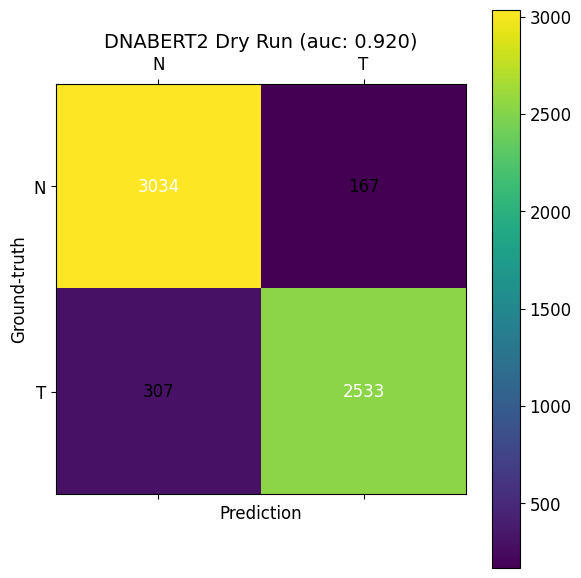

In [8]:
from sklearn.metrics import confusion_matrix, auc, roc_curve
import numpy as np

# Set Matplotlib styling
plt.rcParams.update({
    "font.size": 12,
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "grid.color": "lightgray",
    "grid.linestyle": "-",
})

# Compute confusion matrix
cf_matrix = confusion_matrix(res.label_ids, res.predictions)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="viridis")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(j, i, f"{val}", ha="center", va="center", color="white" if val > cf_matrix.max() / 2 else "black")

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(res.label_ids, res.predictions)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"DNABERT2 Dry Run (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()


### Step 3: Predicting on Synthetic Data Without a Checkpoint

In this section, we'll initialize EpigenDnabert2 without loading a checkpoint. Instead, we'll create synthetic data with varying sequence lengths and optional features such as cpg_methylation and m6a_methylation. We'll then use the model to make predictions on this data.


In [3]:
# Initialize EpigenDnabert2 without a checkpoint
epigenbert_no_checkpoint = EpigenDnabert2(fine_tuned_model_path=None, max_sequence_length=2**16, use_m6a_methylation=True)

# Generate synthetic data
synthetic_data = generate_example_data(
    sequence_length=128, 
    include_cpg_methylation=True, 
    include_m6a_methylation=True, 
    include_labels=False, 
    num_samples=10
)

# Create a dataset from the synthetic data
synthetic_dataset = SupervisedDataset(
    tokenizer=epigenbert_no_checkpoint.tokenizer, 
    data_path_or_list=synthetic_data, 
    kmer=-1
)

# Make predictions on synthetic data
synthetic_predictions = epigenbert_no_checkpoint.predict(synthetic_dataset)

C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\d064dece8a8b41d9fb8729fbe3435278786931f1\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\rizdvanetskyi\Documents\KULeuven-Masters\Master Thesis\methyldl\methyldl\methyldl\modelling\dnabert2.py:456: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return transformers.Trainer(model=self.model,
100%|██████████| 2/2 

### Step 4: Benchmarking Predictions

In this section, we benchmark the model's performance on synthetic data of varying sequence lengths. Specifically, we'll measure:
1. Inference time
2. Allocated RAM during inference

Finally, we'll plot the results to visualize how sequence length affects inference time and RAM usage.


In [14]:
# Benchmarking variables
import numpy as np
sequence_lengths = [2**i for i in range(16) if i >5] # [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
n_repeats = 100
inference_times = {seq_len: [] for seq_len in sequence_lengths}
allocated_ram = {seq_len: [] for seq_len in sequence_lengths}

from IPython.utils import io


for seq_len in tqdm(sequence_lengths, f"Processing {n_repeats} sequences each of length {sequence_lengths}"):
    with io.capture_output() as captured:
        for _ in range(n_repeats):
            # Generate synthetic data for the given sequence length
            synthetic_data = generate_example_data(
                sequence_length=seq_len,
                include_cpg_methylation=True,
                include_m6a_methylation=True,
                include_labels=False,
                num_samples=1  # Single sample per repeat
            )
            synthetic_dataset = SupervisedDataset(
                tokenizer=epigenbert_no_checkpoint.tokenizer,
                data_path_or_list=synthetic_data,
                kmer=-1
            )
            # Measure inference time and allocated RAM
            start_time = time.time()
            torch.cuda.reset_peak_memory_stats()  # Reset RAM tracking if using GPU
            epigenbert_no_checkpoint.predict(synthetic_dataset)
            elapsed_time = time.time() - start_time
            peak_ram = torch.cuda.max_memory_allocated() / (1024 ** 2)  # RAM in MB
            # Store results
            inference_times[seq_len].append(elapsed_time)
            allocated_ram[seq_len].append(peak_ram)


Processing 100 sequences each of length [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]: 100%|██████████| 10/10 [07:43<00:00, 46.35s/it]


### Step 5: Visualizing Benchmark Results

Finally, we'll plot:
1. **Sequence Length vs Inference Time**
2. **Sequence Length vs Allocated RAM**

These plots help us understand the performance characteristics of EpigenDnabert2.

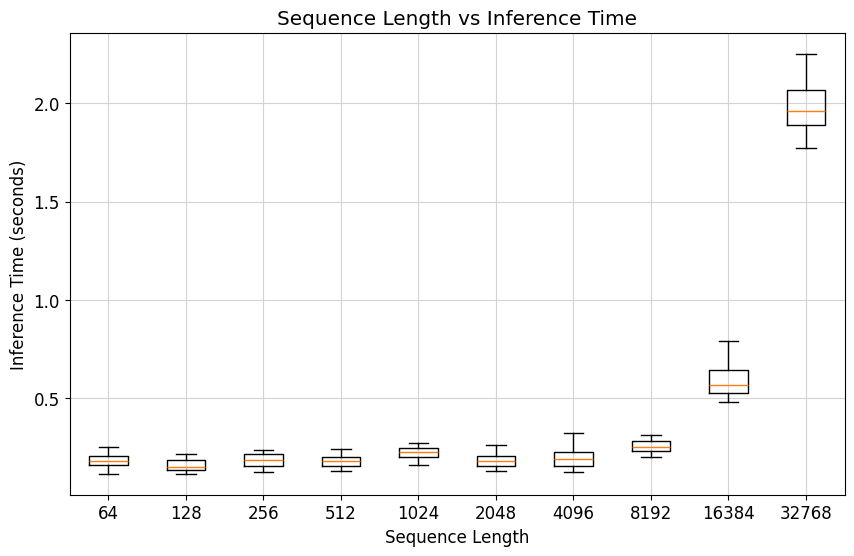

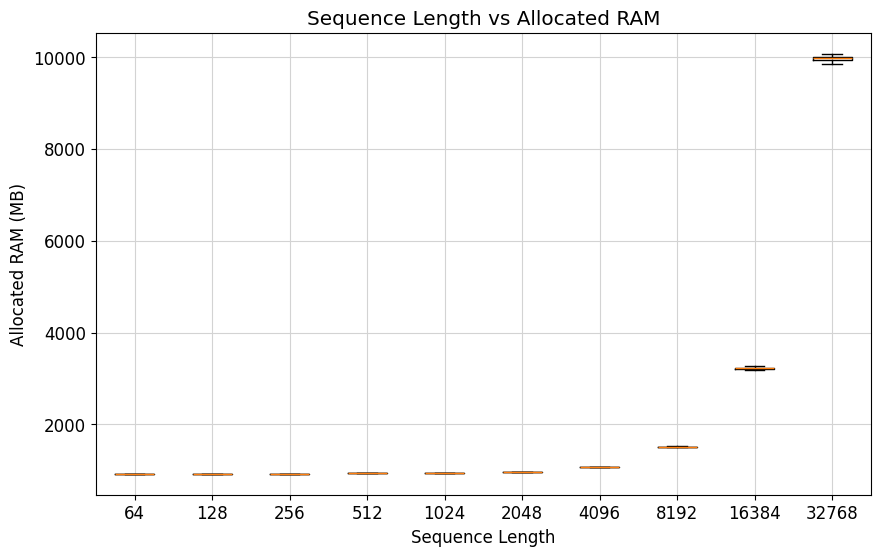

In [15]:
# Convert dictionary results to list for plotting
seq_lengths_list = list(sequence_lengths)

# Inference Time Box Plot
plt.figure(figsize=(10, 6))
plt.boxplot(
    [inference_times[seq_len] for seq_len in seq_lengths_list],
    tick_labels=seq_lengths_list,
    showfliers=False
)
plt.title("Sequence Length vs Inference Time")
plt.xlabel("Sequence Length")
plt.ylabel("Inference Time (seconds)")
plt.grid()
plt.show()

# Allocated RAM Box Plot
plt.figure(figsize=(10, 6))
plt.boxplot(
    [allocated_ram[seq_len] for seq_len in seq_lengths_list],
    tick_labels=seq_lengths_list,
    showfliers=False
)
plt.title("Sequence Length vs Allocated RAM")
plt.xlabel("Sequence Length")
plt.ylabel("Allocated RAM (MB)")
plt.grid()
plt.show()
